# Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler



In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
print(df.tail())

      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


In [7]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [8]:
print(df.describe(include= "all"))

                age   sex          bmi     children smoker     region  \
count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN   676          NaN          NaN   1064        364   
mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
25%       27.000000   NaN    26.296250     0.000000    NaN        NaN   
50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
75%       51.000000   NaN    34.693750     2.000000    NaN        NaN   
max       64.000000   NaN    53.130000     5.000000    NaN        NaN   

             charges  
count    1338.000000  
unique           NaN  
top              NaN  
freq             NaN  
mean    

In [9]:
name = []
data_type = []
nunique = []
unique = []
for col in df.columns:
    name.append(df[col].name)
    data_type.append(df[col].dtype)
    nunique.append(df[col].nunique())
    if df[col].nunique() <= 6:
        unique.append(df[col].unique())
    else:
        unique.append("too big to add")
name_dtype_nunique = pd.DataFrame({"Data Type": data_type,
                                   "Number of Unique": nunique,
                                   "Unique Values": unique}, index=name)
print(name_dtype_nunique.T)


                             age             sex             bmi  \
Data Type                  int64             str         float64   
Number of Unique              47               2             548   
Unique Values     too big to add  [female, male]  too big to add   

                            children     smoker  \
Data Type                      int64        str   
Number of Unique                   6          2   
Unique Values     [0, 1, 3, 2, 5, 4]  [yes, no]   

                                                        region         charges  
Data Type                                                  str         float64  
Number of Unique                                             4            1337  
Unique Values     [southwest, southeast, northwest, northeast]  too big to add  


# Drop non-intresting features
Nothing to drop

# Check data types and handle them

In [10]:
cat_cols = ["sex", "children", "smoker", "region"]
num_cols = ["age", "bmi", "charges"]


In [11]:
df[cat_cols] = df[cat_cols].astype('category')

# Check nulls and handle them
There is no nulls at all

# Check outliers and handle them

In [12]:
q1 = []
q3 = []
iqr = []
lower_fence = []
upper_fence = []
lower_outliers = []
upper_outliers = []
extreme_lower_fence = []
extreme_upper_fence = []
extreme_lower_outliers = []
extreme_upper_outliers = []
difference_between_no_upper = []
difference_between_no_lower = []
len_lower_outliers = []
len_upper_outliers = []
len_extreme_lower_outliers = []
len_extreme_upper_outliers = []
for col in num_cols:
    q1.append(df[col].quantile(0.25))
    q3.append(df[col].quantile(0.75))
    iqr.append(q3[-1] - q1[-1])
    lower_fence.append(q1[-1] - (1.5 * iqr[-1]))
    upper_fence.append(q3[-1] + (1.5 * iqr[-1]))
    extreme_lower_fence.append(q1[-1] - (3 * iqr[-1]))
    extreme_upper_fence.append(q3[-1] + (3 * iqr[-1]))
    lower_outliers.append(df[df[col] < lower_fence[-1]][col].values)
    upper_outliers.append(df[df[col] > upper_fence[-1]][col].values)
    len_lower_outliers.append(len(lower_outliers[-1]))
    len_upper_outliers.append(len(upper_outliers[-1]))
    extreme_lower_outliers.append(df[df[col] < extreme_lower_fence[-1]][col].values)
    extreme_upper_outliers.append(df[df[col] > extreme_upper_fence[-1]][col].values)
    len_extreme_lower_outliers.append(len(extreme_lower_outliers[-1]))
    len_extreme_upper_outliers.append(len(extreme_upper_outliers[-1]))
    difference_between_no_upper.append(len(upper_outliers[-1]) - len(extreme_upper_outliers[-1]))
    difference_between_no_lower.append(len(lower_outliers[-1]) - len(extreme_lower_outliers[-1]))

outliers = pd.DataFrame({
    'Q1': q1,
    'Q3': q3,
    'IQR': iqr,
    'Lower Fence': lower_fence,
    'Upper Fence': upper_fence,
    'Extreme Lower Fence': extreme_lower_fence,
    'Extreme Upper Fence': extreme_upper_fence,
    'Lower Outliers': lower_outliers,
    'Upper Outliers': upper_outliers,
    'Length of Lower Outliers': len_lower_outliers,
    'Length of Upper Outliers': len_upper_outliers,
    'Length of Extreme Lower Outliers': len_extreme_lower_outliers,
    'Length of Extreme Upper Outliers': len_extreme_upper_outliers,
    'Extreme Lower Outliers': extreme_lower_outliers,
    'Extreme Upper Outliers': extreme_upper_outliers,
    'Difference Between Number of Upper Outliers and Extreme Upper Outliers': difference_between_no_upper,
    'Difference Between Number of Lower Outliers and Extreme Lower Outliers': difference_between_no_lower,
}, index = num_cols).T
outliers


,age,bmi,charges
Q1,27.0,26.29625,4740.28715
Q3,51.0,34.69375,16639.912515
IQR,24.0,8.3975,11899.625365
Lower Fence,-9.0,13.7,-13109.150897
Upper Fence,87.0,47.29,34489.350562
Extreme Lower Fence,-45.0,1.10375,-30958.588945
Extreme Upper Fence,123.0,59.88625,52338.78861
Lower Outliers,[],[],[]
Upper Outliers,[],"[49.06, 48.07, 47.52, 47.41, 50.38, 47.6, 52.5...","[39611.7577, 36837.467, 37701.8768, 38711.0, 3..."
Length of Lower Outliers,0,0,0


In [13]:
# Is there any negative values or zeros in age?
print(df[df.age <= 0], '\n')
# Is there any negative values or zeros in BMI?
print(df[df.bmi <= 0], '\n')
# checking with least humanliy possible BMI?
print(df[df.bmi <= 11], '\n')

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: [] 

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: [] 

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: [] 



In [14]:
# Largest BMI and how many of them
print(df[df.bmi == df.bmi.max()], '\nnumbers:', df[df.bmi == df.bmi.max()]['bmi'].count(), '\n')
# Oldest Person, Youngest Person and how many of them
print(df[df.age == df.age.max()], '\nnumbers:', df[df.age == df.age.max()]['age'].count(), '\n')
print(df[df.age == df.age.min()], '\nnumbers:', df[df.age == df.age.min()]['age'].count(), '\n')
# Largest Charge and Lowest one, and how many of them
print(df[df.charges == df.charges.max()], '\nnumbers:', df[df.charges == df.charges.max()]['charges'].count())
print(df[df.charges == df.charges.min()], '\nnumbers:', df[df.charges == df.charges.min()]['charges'].count())


      age   sex    bmi children smoker     region    charges
1317   18  male  53.13        0     no  southeast  1163.4627 
numbers: 1 

      age     sex     bmi children smoker     region      charges
62     64    male  24.700        1     no  northwest  30166.61817
94     64  female  31.300        2    yes  southwest  47291.05500
199    64  female  39.330        0     no  northeast  14901.51670
328    64  female  33.800        1    yes  southwest  47928.03000
335    64    male  34.500        0     no  southwest  13822.80300
378    64  female  30.115        3     no  northwest  16455.70785
398    64    male  25.600        2     no  southwest  14988.43200
402    64  female  32.965        0     no  northwest  14692.66935
418    64    male  39.160        1     no  southeast  14418.28040
420    64    male  33.880        0    yes  southeast  46889.26120
534    64    male  40.480        0     no  southeast  13831.11520
603    64  female  39.050        3     no  southeast  16085.12750
635   

##### I used the IQR method for outliers detection but I won't be dropping or handling any of them, because everything in these extremes is possible

# Checking Duplicates and Handling them
There are many Duplicates in the data, but I chose to Leave them as they are, they wouldn't affect the data

# Data Visualization

In [15]:
bmi_meter = pd.DataFrame({'bmi_meter': ['underweight', 'normal', 'overweight', 'obeseI', 'obeseII', 'obeseIII']})
df = pd.concat([df, bmi_meter], axis= 1)
df.loc[df.bmi < 18.5, 'bmi_meter'] = "underweight"
df.loc[df.bmi.between(18.500, 25.000, inclusive= 'left'), 'bmi_meter'] = "normal"
df.loc[df.bmi.between(25.000, 30.000, inclusive= 'left'), 'bmi_meter'] = "overweight"
df.loc[df.bmi.between(30.000, 35.000, inclusive= 'left'), 'bmi_meter'] = "obeseI"
df.loc[df.bmi.between(35.000, 40.000, inclusive= 'left'), 'bmi_meter'] = "obeseII"
df.loc[df.bmi >= 40.000, 'bmi_meter'] = "obeseIII"

print(
df[df.bmi < 18.500])

      age     sex     bmi children smoker     region      charges    bmi_meter
28     23    male  17.385        1     no  northwest   2775.19215  underweight
128    32  female  17.765        2    yes  northwest  32734.18630  underweight
172    18    male  15.960        0     no  northeast   1694.79640  underweight
198    51  female  18.050        0     no  northwest   9644.25250  underweight
232    19  female  17.800        0     no  southwest   1727.78500  underweight
250    18    male  17.290        2    yes  northeast  12829.45510  underweight
380    27  female  17.955        2    yes  northeast  15006.57945  underweight
410    19    male  17.480        0     no  northwest   1621.34020  underweight
412    26  female  17.195        2    yes  northeast  14455.64405  underweight
428    21  female  16.815        1     no  northeast   3167.45585  underweight
680    21  female  17.400        1     no  southwest   2585.26900  underweight
821    26    male  17.670        0     no  northwest

In [16]:
df['bmi_meter'] = df.bmi_meter.astype('category')
df.select_dtypes('category')

,sex,children,smoker,region,bmi_meter
0,female,0,yes,southwest,overweight
1,male,1,no,southeast,obeseI
2,male,3,no,southeast,obeseI
3,male,0,no,northwest,normal
4,male,0,no,northwest,overweight
...,...,...,...,...,...
1333,male,3,no,northwest,obeseI
1334,female,0,no,northeast,obeseI
1335,female,0,no,southeast,obeseII
1336,female,0,no,southwest,overweight


It is widely known that women get fatter much easier cause of high estorgen hormone in their body\
Let's check if this is true in our data or not

In [17]:
cross_table = pd.crosstab(
    index= df.sex,
    columns= df.bmi_meter,
    normalize= 'index'
) * 100
print(cross_table)

bmi_meter     normal     obeseI    obeseII  obeseIII  overweight  underweight
sex                                                                          
female     17.673716  28.247734  16.163142  6.042296   30.060423     1.812689
male       15.976331  30.177515  17.455621  7.544379   27.662722     1.183432


<Axes: xlabel='sex'>

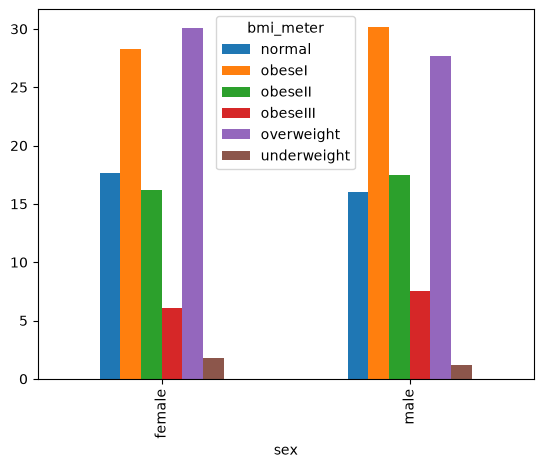

In [18]:
cross_table.plot.bar()
#this is good but we can't see clearly

In [19]:
collapse_map = {
    'normal' : 'Healthy (Normal)',
    'overweight' : 'Unhealthy (above normal)',
    'obeseI' : 'Unhealthy (above normal)',
    'obeseII' : 'Unhealthy (above normal)',
    'obeseIII' : 'Unhealthy (above normal)'
}

# Added .astype(str) to unlock the categorical restrictions
df['simplified_bmi'] = df['bmi_meter'].astype(str).replace(collapse_map)

df_filtered = df[df['simplified_bmi'] != 'underweight']

cross_table = pd.crosstab(
    index= df_filtered.sex,
    columns= df_filtered.simplified_bmi,
    normalize= 'index'
) * 100

<Axes: xlabel='sex'>

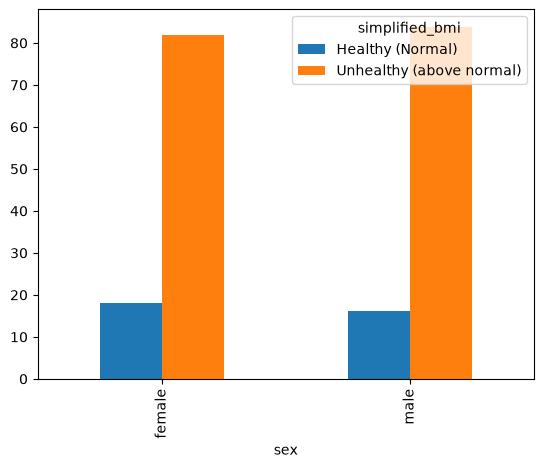

In [20]:
cross_table.plot.bar()

#### this is AI generated without much understanding

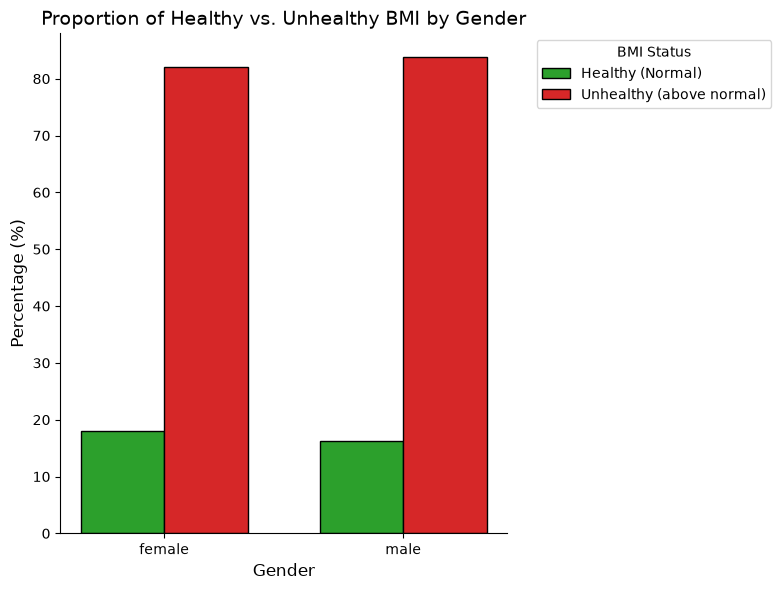

In [21]:
# 1. Extract the data
genders = cross_table.index 
healthy_pct = cross_table['Healthy (Normal)']
unhealthy_pct = cross_table['Unhealthy (above normal)']

# 2. Set up the x-axis positions and bar width
x = np.arange(len(genders))  # Creates numeric positions: [0, 1]
width = 0.35                 # Sets the thickness of each bar

# 3. Set up the canvas
plt.figure(figsize=(8, 6))

# 4. Draw the bars side-by-side by shifting their x-positions
# We subtract width/2 to push Healthy to the left
plt.bar(
    x=x - width/2, 
    height=healthy_pct, 
    width=width, 
    color='#2ca02c', 
    edgecolor='black', 
    label='Healthy (Normal)'
)

# We add width/2 to push Unhealthy to the right
plt.bar(
    x=x + width/2, 
    height=unhealthy_pct, 
    width=width, 
    color='#d62728', 
    edgecolor='black', 
    label='Unhealthy (above normal)'
)

# 5. Formatting
plt.title('Proportion of Healthy vs. Unhealthy BMI by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Replace the numeric x-axis ticks (0, 1) with the actual gender names
plt.xticks(x, genders)

# Move the legend outside the chart
plt.legend(title='BMI Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Render the chart
plt.tight_layout()
plt.show()

 We can see that it is about the same\
 Although females are a little bit healther and less obese, while males are a little bit less healthy and more obese\
 This facinating because the number of males are much higher than females\

 How about another question: let's see the relation between healthy people and charges, and the relation between age and charges\
 #### This is AI generated:

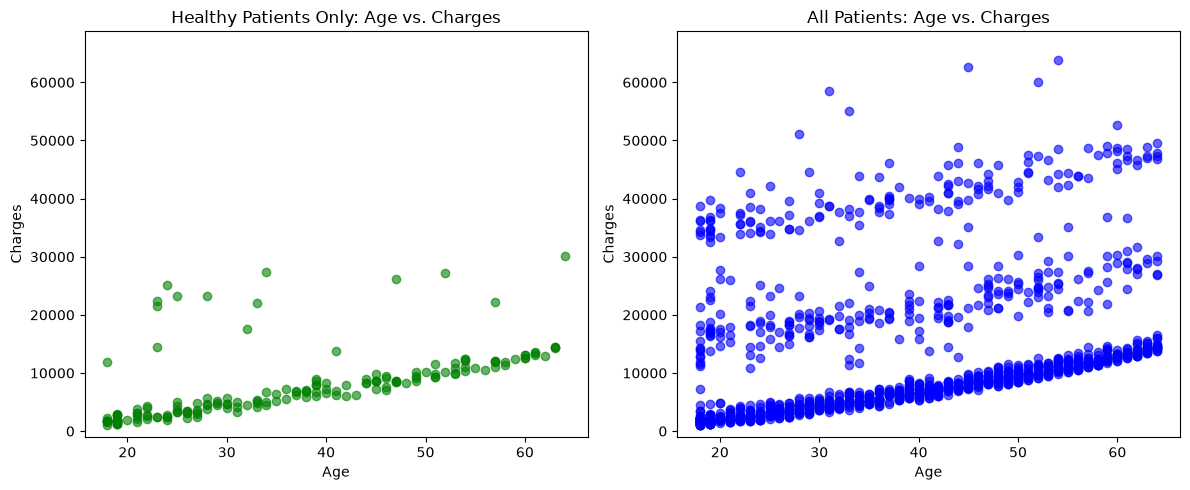

In [22]:
# 1. Map the BMI categories (including underweight as unhealthy)
collapse_map = {
    'underweight': 'Unhealthy (below normal)', 
    'normal': 'Healthy (Normal)',
    'overweight': 'Unhealthy (above normal)',
    'obeseI': 'Unhealthy (above normal)',
    'obeseII': 'Unhealthy (above normal)',
    'obeseIII': 'Unhealthy (above normal)'
}

# Apply the mapping
df['simplified_bmi'] = df['bmi_meter'].astype(str).replace(collapse_map)

# 2. Filter the dataset for strictly Healthy patients 
healthy_df = df[(df['smoker'] == 'no') & (df['simplified_bmi'] == 'Healthy (Normal)')]

# 3. Set up the canvas for side-by-side plots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Plot 1: Age vs. Charges (Healthy Patients ONLY)
ax1.scatter(x=healthy_df['age'], y=healthy_df['charges'], color='green', alpha=0.6)
ax1.set_title('Healthy Patients Only: Age vs. Charges')
ax1.set_xlabel('Age')
ax1.set_ylabel('Charges')

# Plot 2: Age vs. Charges (All Patients)
ax2.scatter(x=df['age'], y=df['charges'], color='blue', alpha=0.6)
ax2.set_title('All Patients: Age vs. Charges')
ax2.set_xlabel('Age')
ax2.set_ylabel('Charges')

# 4. Lock the y-axis scales so they match perfectly for visual comparison
max_charge = df['charges'].max()
ax1.set_ylim(-1000, max_charge + 5000)
ax2.set_ylim(-1000, max_charge + 5000)

# Clean up layout and render
plt.tight_layout()
plt.show()

# Spliting, Normalization, Encoding

In [26]:
df.simplified_bmi = df.simplified_bmi.astype('category')

In [27]:
x = df.drop('simplified_bmi', axis = 1) 
y = df[["simplified_bmi"]]

In [30]:
scaler = MinMaxScaler()
scaler.fit(x[num_cols])
x[num_cols] = scaler.transform(x[num_cols])
x.head()

,age,sex,bmi,children,smoker,region,charges,bmi_meter
0,0.021739,female,0.321227,0,yes,southwest,0.251611,overweight
1,0.000000,male,0.479150,1,no,southeast,0.009636,obeseI
2,0.217391,male,0.458434,3,no,southeast,0.053115,obeseI
3,0.326087,male,0.181464,0,no,northwest,0.333010,normal
4,0.304348,male,0.347592,0,no,northwest,0.043816,overweight


In [31]:
encoder = OneHotEncoder(cols = cat_cols, drop_invariant= True)
x = encoder.fit_transform(x)
x.head()

,age,sex_1,sex_2,bmi,children_1,children_2,children_3,children_4,children_5,children_6,smoker_1,smoker_2,region_1,region_2,region_3,region_4,charges,bmi_meter
0,0.021739,1,0,0.321227,1,0,0,0,0,0,1,0,1,0,0,0,0.251611,overweight
1,0.000000,0,1,0.479150,0,1,0,0,0,0,0,1,0,1,0,0,0.009636,obeseI
2,0.217391,0,1,0.458434,0,0,1,0,0,0,0,1,0,1,0,0,0.053115,obeseI
3,0.326087,0,1,0.181464,1,0,0,0,0,0,0,1,0,0,1,0,0.333010,normal
4,0.304348,0,1,0.347592,1,0,0,0,0,0,0,1,0,0,1,0,0.043816,overweight
